In [102]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
import xarray as xr
import numpy as np

In [103]:
zthr = 200

parent = '../data/timeseries/'
child_yes = 'vmax_th_2bf.nc'
child_no = 'vmax_th_no_grf.nc'

# time_coder = xr.coders.CFDatetimeCoder(use_cftime=False)

ds_no = xr.open_dataset(parent+child_no, decode_times=False)
ds_yes = xr.open_dataset(parent+child_yes, decode_times=False)

nongrf1, grf1, nongrf3, grf3 = [], [], [], []
times1, times3 = [], []

for i in range(ds_no['deltav'].size):
	if ds_no['zmin'][i] < zthr:
		nongrf1.append(ds_no['deltav'][i])
		times1.append(ds_no['time'][i])
	else:
		nongrf3.append(ds_no['deltav'][i])
		times3.append(ds_no['time'][i])

for i in range(ds_yes['deltav'].size):
	if ds_yes['zmin'][i] < zthr:
		grf1.append(ds_yes['deltav'][i])
	else:
		grf3.append(ds_yes['deltav'][i])

In [104]:
interptimes = np.linspace(0, np.nanmax(ds_no['time']), 100)

nongrf1_interp = np.interp(interptimes, times1, nongrf1)
grf1_interp = np.interp(interptimes, times1, grf1)
nongrf3_interp = np.interp(interptimes, times3, nongrf3)
grf3_interp = np.interp(interptimes, times3, grf3)

corr_1 = np.corrcoef(nongrf1_interp, y=grf1_interp)
corr_3 = np.corrcoef(nongrf3_interp, y=grf3_interp)

corr_13_no = np.corrcoef(nongrf1_interp, y=nongrf3_interp)
corr_13_yes = np.corrcoef(grf1_interp, y=grf3_interp)

print(f'Correlation Coefficient at 1º: {corr_1[0][1]:.4f}')
print(f'Correlation Coefficient at 3º: {corr_3[0][1]:.4f}')

print(f'Correlation Coefficient Between 1º and 3º, No-GRF: {corr_13_no[0][1]:.4f}')
print(f'Correlation Coefficient Between 1º and 3º, GRF: {corr_13_yes[0][1]:.4f}')

Correlation Coefficient at 1º: 0.6400
Correlation Coefficient at 3º: 0.9535
Correlation Coefficient Between 1º and 3º, No-GRF: 0.0665
Correlation Coefficient Between 1º and 3º, GRF: 0.2999


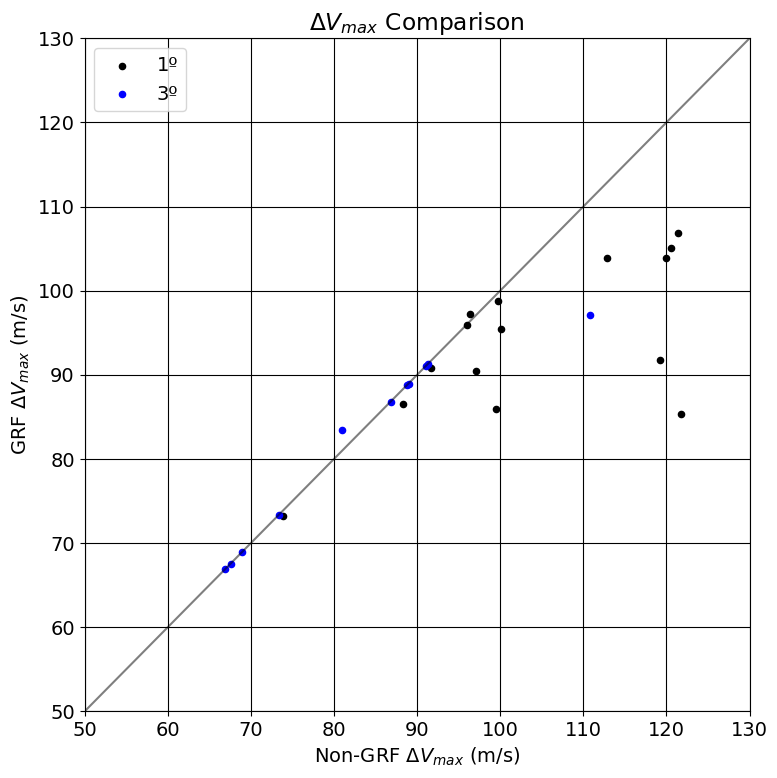

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.set_xlabel('Non-GRF $\Delta V_{max}$ (m/s)')
ax.set_ylabel('GRF $\Delta V_{max}$ (m/s)')
ax.set_title('$\Delta V_{max}$ Comparison')

ax.grid(visible=True, c=(0, 0, 0, 0.5))
ax.plot([0,150], [0,150], c=(0, 0, 0, 0.5))
ax.scatter(nongrf1, grf1, c='k', s=20, label='1º')
ax.scatter(nongrf3, grf3, c='b', s=20, label='3º')

ax.set_xlim(50, 130)
ax.set_ylim(50, 130)

ax.legend()

plt.tight_layout()
plt.savefig('scatter.png')
plt.show()